In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error,
    classification_report, confusion_matrix, accuracy_score
)
import xgboost as xgb
import shap

# Reproducibility
np.random.seed(42)

print('All libraries imported successfully ✅')

All libraries imported successfully ✅


In [2]:

df = pd.read_csv('ai_job_replacement_2020_2026_v2.csv')

print(f'Shape: {df.shape}')
df.head()

Shape: (15000, 20)


,job_id,job_role,industry,country,year,automation_risk_percent,ai_replacement_score,skill_gap_index,salary_before_usd,salary_after_usd,salary_change_percent,skill_demand_growth_percent,remote_feasibility_score,ai_adoption_level,education_requirement_level,automation_risk_category,skill_transition_pressure,wage_volatility_index,reskilling_urgency_score,ai_disruption_intensity
0,0,Data Analyst,Technology,Canada,2021,26.22,30.94,73.20,101839.02,99454.42,-2.34,2.66,15.23,86.62,2,Low,49.710,2.34,33.150,22.711764
1,1,Accountant,Finance,Brazil,2020,52.08,56.41,2.06,146389.18,139516.59,-4.69,10.43,26.36,18.34,5,Medium,27.070,4.69,22.857,9.551472
2,2,Teacher,Technology,USA,2020,31.30,31.61,43.19,64947.50,58369.41,-10.13,8.14,36.29,36.64,2,Medium,37.245,10.13,28.516,11.468320
3,3,Customer Support Rep,Technology,Brazil,2021,56.92,63.42,19.97,91708.13,86715.70,-5.44,6.11,64.68,17.05,5,Medium,38.445,5.44,30.391,9.704860
4,4,Teacher,Manufacturing,Japan,2024,14.55,17.17,96.56,127007.68,119379.11,-6.01,2.08,71.58,44.02,3,Low,55.555,6.01,36.591,6.404910


In [3]:
# Basic info
print('=== Dataset Info ===')
df.info()
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Statistical Summary ===')
df.describe().round(2)

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   job_id                       15000 non-null  int64  
 1   job_role                     15000 non-null  object 
 2   industry                     15000 non-null  object 
 3   country                      15000 non-null  object 
 4   year                         15000 non-null  int64  
 5   automation_risk_percent      15000 non-null  float64
 6   ai_replacement_score         15000 non-null  float64
 7   skill_gap_index              15000 non-null  float64
 8   salary_before_usd            15000 non-null  float64
 9   salary_after_usd             15000 non-null  float64
 10  salary_change_percent        15000 non-null  float64
 11  skill_demand_growth_percent  15000 non-null  float64
 12  remote_feasibility_score     15000 non-null  float64


,job_id,year,automation_risk_percent,ai_replacement_score,skill_gap_index,salary_before_usd,salary_after_usd,salary_change_percent,skill_demand_growth_percent,remote_feasibility_score,ai_adoption_level,education_requirement_level,skill_transition_pressure,wage_volatility_index,reskilling_urgency_score,ai_disruption_intensity
count,15000.00,15000.0,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00
mean,7499.50,2023.0,46.18,46.16,50.00,89771.38,89870.63,0.11,5.02,54.90,49.80,3.02,48.09,7.99,35.87,23.01
std,4330.27,2.0,21.66,22.35,28.81,34522.13,35897.59,10.03,9.96,25.86,28.86,1.41,18.11,6.07,12.42,18.24
min,0.00,2020.0,5.00,4.01,0.00,30003.69,19022.67,-38.37,-31.88,10.01,0.01,1.00,2.98,0.00,2.46,0.00
25%,3749.75,2021.0,28.79,28.36,25.17,60127.23,59223.46,-6.64,-1.66,32.52,24.71,2.00,34.90,3.21,26.98,8.23
50%,7499.50,2023.0,46.24,45.68,49.93,89533.05,88787.33,0.15,4.96,54.78,49.44,3.00,48.16,6.66,35.87,18.64
75%,11249.25,2025.0,63.60,62.71,75.03,119823.84,118432.97,6.69,11.73,77.40,74.80,4.00,61.30,11.55,44.70,34.09
max,14999.00,2026.0,94.98,113.07,99.98,149984.06,191961.21,36.92,49.79,99.99,99.98,5.00,96.34,38.37,71.58,93.35


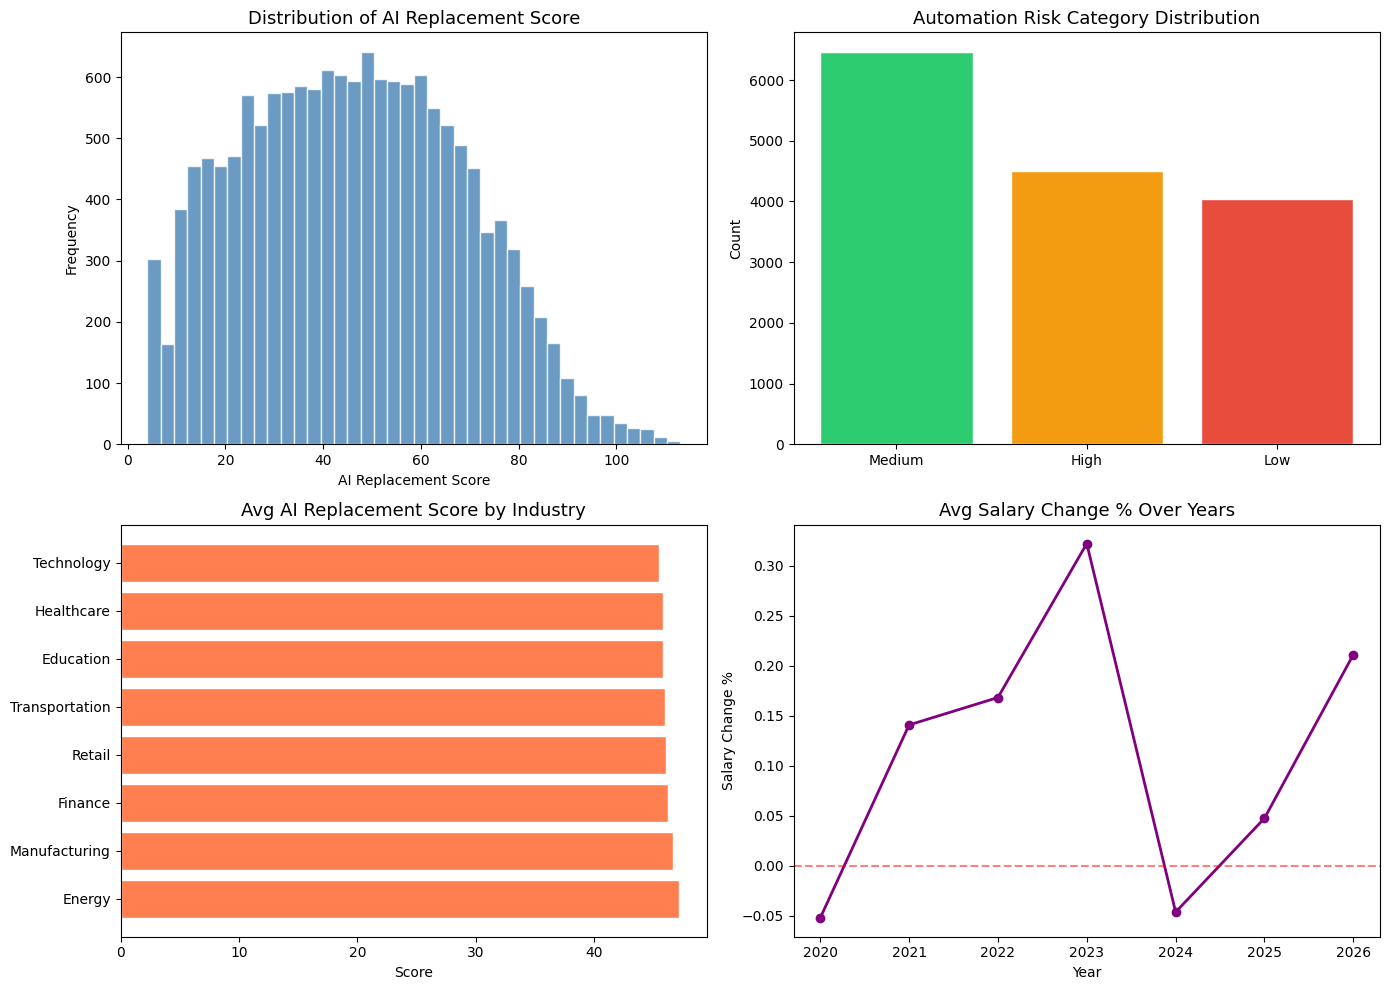

EDA plots saved ✅


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Target distribution
axes[0, 0].hist(df['ai_replacement_score'], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0, 0].set_title('Distribution of AI Replacement Score', fontsize=13)
axes[0, 0].set_xlabel('AI Replacement Score')
axes[0, 0].set_ylabel('Frequency')

# 2. Automation risk category
cat_counts = df['automation_risk_category'].value_counts()
axes[0, 1].bar(cat_counts.index, cat_counts.values, color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='white')
axes[0, 1].set_title('Automation Risk Category Distribution', fontsize=13)
axes[0, 1].set_ylabel('Count')

# 3. AI replacement by industry
ind_avg = df.groupby('industry')['ai_replacement_score'].mean().sort_values(ascending=False)
axes[1, 0].barh(ind_avg.index, ind_avg.values, color='coral', edgecolor='white')
axes[1, 0].set_title('Avg AI Replacement Score by Industry', fontsize=13)
axes[1, 0].set_xlabel('Score')

# 4. Salary change over years
yearly = df.groupby('year')['salary_change_percent'].mean()
axes[1, 1].plot(yearly.index, yearly.values, marker='o', color='purple', linewidth=2)
axes[1, 1].set_title('Avg Salary Change % Over Years', fontsize=13)
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Salary Change %')
axes[1, 1].axhline(0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('eda_job_replacement.png', dpi=120, bbox_inches='tight')
plt.show()
print('EDA plots saved ✅')

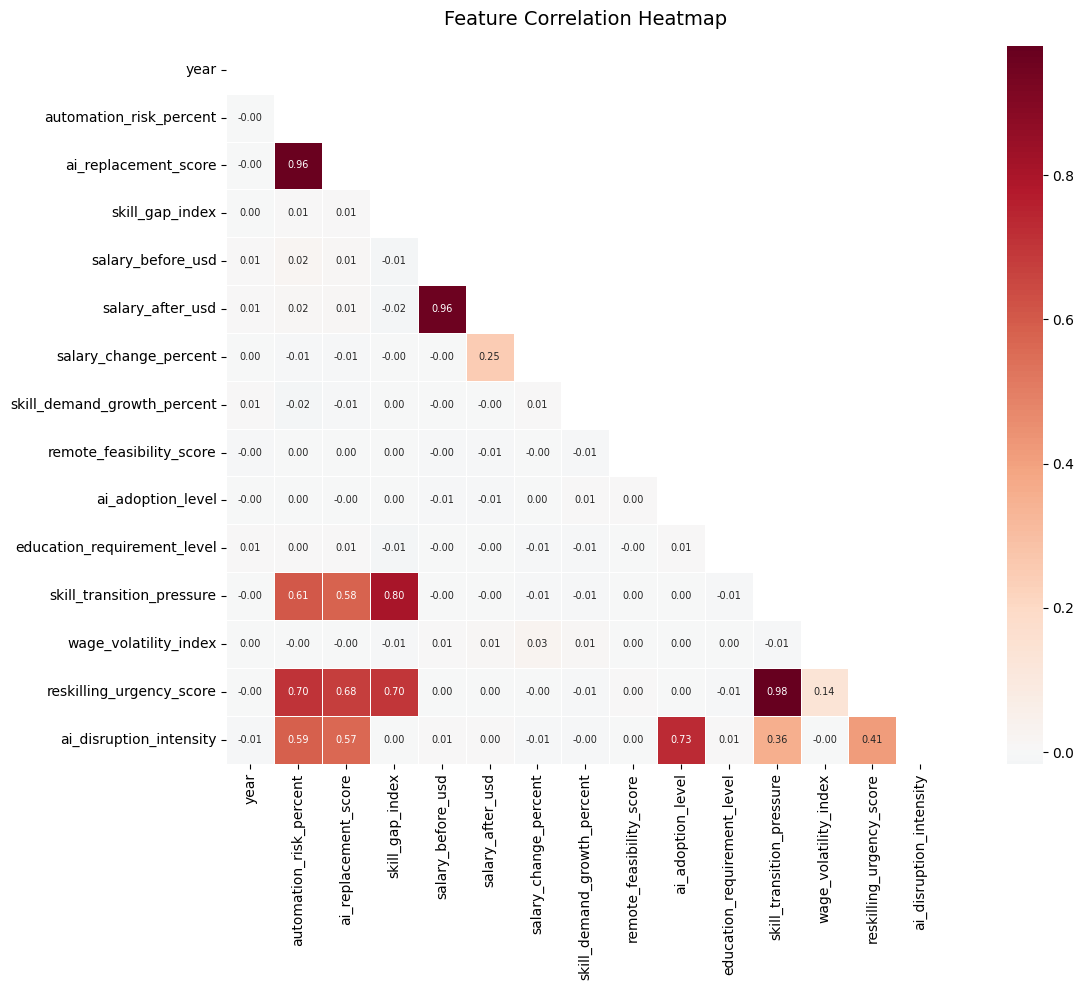

In [5]:
# Correlation heatmap (numeric only)
numeric_cols = df.select_dtypes(include=[np.number]).drop(columns=['job_id'])
plt.figure(figsize=(14, 10))
corr = numeric_cols.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, annot_kws={'size': 7})
plt.title('Feature Correlation Heatmap', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

In [6]:
df_processed = df.copy()

# --- Encode categoricals ---
le_dict = {}
cat_cols = ['job_role', 'industry', 'country', 'automation_risk_category']
for col in cat_cols:
    le = LabelEncoder()
    df_processed[col + '_enc'] = le.fit_transform(df_processed[col])
    le_dict[col] = le
    print(f'{col} → {le.classes_}')

# --- Feature set (drop raw categoricals + IDs + leakage cols) ---
LEAKAGE = ['ai_replacement_score', 'automation_risk_category',
           'automation_risk_category_enc', 'job_id',
           'job_role', 'industry', 'country']

feature_cols = [c for c in df_processed.columns if c not in LEAKAGE]
print('\nFeatures used:', feature_cols)

X = df_processed[feature_cols]

# Regression target
y_reg = df_processed['ai_replacement_score']

# Classification target
y_clf = df_processed['automation_risk_category_enc']
risk_labels = le_dict['automation_risk_category'].classes_
print('\nRisk label mapping:', dict(enumerate(risk_labels)))

job_role → ['Accountant' 'Customer Support Rep' 'Data Analyst' 'Financial Analyst'
 'HR Manager' 'Marketing Specialist' 'Mechanical Engineer'
 'Software Engineer' 'Teacher' 'Truck Driver']
industry → ['Education' 'Energy' 'Finance' 'Healthcare' 'Manufacturing' 'Retail'
 'Technology' 'Transportation']
country → ['Australia' 'Brazil' 'Canada' 'Germany' 'India' 'Japan' 'Singapore' 'UK'
 'USA']
automation_risk_category → ['High' 'Low' 'Medium']

Features used: ['year', 'automation_risk_percent', 'skill_gap_index', 'salary_before_usd', 'salary_after_usd', 'salary_change_percent', 'skill_demand_growth_percent', 'remote_feasibility_score', 'ai_adoption_level', 'education_requirement_level', 'skill_transition_pressure', 'wage_volatility_index', 'reskilling_urgency_score', 'ai_disruption_intensity', 'job_role_enc', 'industry_enc', 'country_enc']

Risk label mapping: {0: 'High', 1: 'Low', 2: 'Medium'}


In [7]:
# Train/test split (80/20, stratified for classification)
X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)
_, _, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print(f'Train size: {X_train.shape[0]:,}  |  Test size: {X_test.shape[0]:,}')
print(f'Classification class balance (train):\n{pd.Series(y_train_clf).value_counts()}')

Train size: 12,000  |  Test size: 3,000
Classification class balance (train):
automation_risk_category_enc
2    5171
0    3597
1    3232
Name: count, dtype: int64


In [8]:
# ── 5A. Regression ──
rf_reg = RandomForestRegressor(n_estimators=200, max_depth=12,
                                min_samples_split=5, n_jobs=-1, random_state=42)
rf_reg.fit(X_train, y_train_reg)
y_pred_rf_reg = rf_reg.predict(X_test)

rf_reg_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_rf_reg))
rf_reg_r2   = r2_score(y_test_reg, y_pred_rf_reg)
rf_reg_mae  = mean_absolute_error(y_test_reg, y_pred_rf_reg)

print('=== Random Forest — Regression ===')
print(f'  RMSE : {rf_reg_rmse:.4f}')
print(f'  R²   : {rf_reg_r2:.4f}')
print(f'  MAE  : {rf_reg_mae:.4f}')

=== Random Forest — Regression ===
  RMSE : 6.0137
  R²   : 0.9272
  MAE  : 4.6890


=== Random Forest — Classification ===
  Accuracy: 0.4303
              precision    recall  f1-score   support

        High       0.38      0.02      0.05       899
         Low       0.25      0.00      0.01       808
      Medium       0.43      0.98      0.60      1293

    accuracy                           0.43      3000
   macro avg       0.35      0.34      0.22      3000
weighted avg       0.37      0.43      0.27      3000



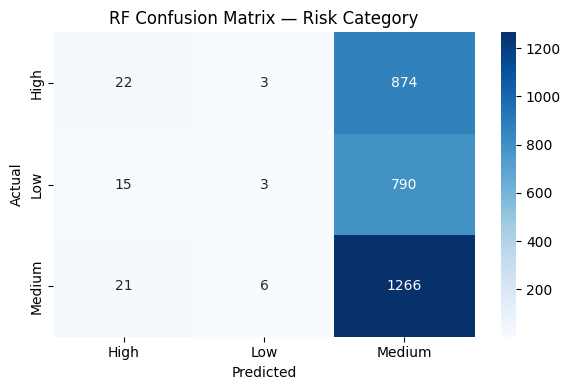

In [9]:
# ── 5B. Classification ──
rf_clf = RandomForestClassifier(n_estimators=200, max_depth=12,
                                 min_samples_split=5, n_jobs=-1, random_state=42)
rf_clf.fit(X_train, y_train_clf)
y_pred_rf_clf = rf_clf.predict(X_test)

print('=== Random Forest — Classification ===')
print(f'  Accuracy: {accuracy_score(y_test_clf, y_pred_rf_clf):.4f}')
print(classification_report(y_test_clf, y_pred_rf_clf, target_names=risk_labels))

# Confusion matrix
cm = confusion_matrix(y_test_clf, y_pred_rf_clf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=risk_labels, yticklabels=risk_labels)
plt.title('RF Confusion Matrix — Risk Category')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('rf_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

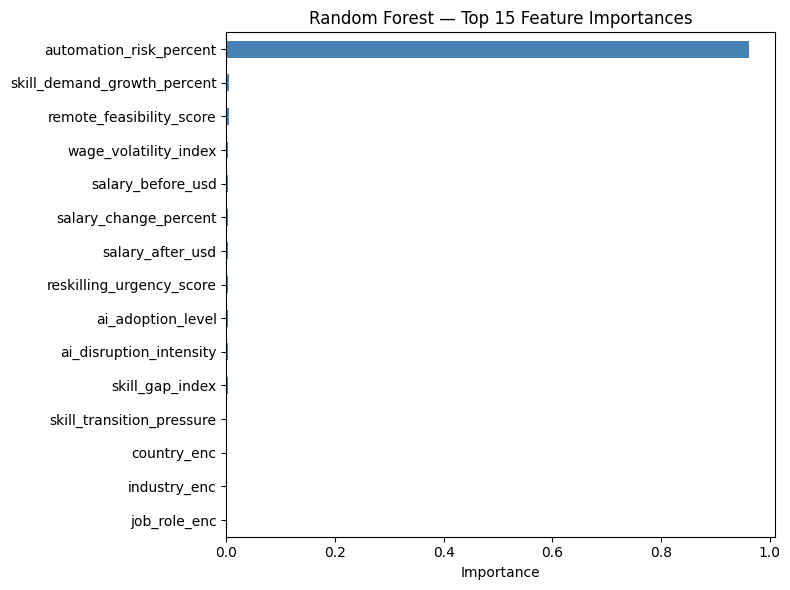

In [10]:
# Feature importance from RF
fi_rf = pd.Series(rf_reg.feature_importances_, index=feature_cols).sort_values(ascending=True)
plt.figure(figsize=(8, 6))
fi_rf.tail(15).plot(kind='barh', color='steelblue')
plt.title('Random Forest — Top 15 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

In [11]:
# ── 6A. Regression ──
gb_reg = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                    max_depth=5, subsample=0.8, random_state=42)
gb_reg.fit(X_train, y_train_reg)
y_pred_gb_reg = gb_reg.predict(X_test)

gb_reg_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_gb_reg))
gb_reg_r2   = r2_score(y_test_reg, y_pred_gb_reg)
gb_reg_mae  = mean_absolute_error(y_test_reg, y_pred_gb_reg)

print('=== Gradient Boosting — Regression ===')
print(f'  RMSE : {gb_reg_rmse:.4f}')
print(f'  R²   : {gb_reg_r2:.4f}')
print(f'  MAE  : {gb_reg_mae:.4f}')

=== Gradient Boosting — Regression ===
  RMSE : 6.0540
  R²   : 0.9262
  MAE  : 4.7193


In [12]:
# ── 6B. Classification ──
gb_clf = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                     max_depth=5, subsample=0.8, random_state=42)
gb_clf.fit(X_train, y_train_clf)
y_pred_gb_clf = gb_clf.predict(X_test)

print('=== Gradient Boosting — Classification ===')
print(f'  Accuracy: {accuracy_score(y_test_clf, y_pred_gb_clf):.4f}')
print(classification_report(y_test_clf, y_pred_gb_clf, target_names=risk_labels))

=== Gradient Boosting — Classification ===
  Accuracy: 0.4183
              precision    recall  f1-score   support

        High       0.30      0.08      0.13       899
         Low       0.34      0.05      0.09       808
      Medium       0.43      0.88      0.58      1293

    accuracy                           0.42      3000
   macro avg       0.36      0.34      0.27      3000
weighted avg       0.37      0.42      0.31      3000



In [13]:
# ── 7A. Regression ──
xgb_reg = xgb.XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1,
    reg_lambda=1.0, random_state=42, tree_method='hist', verbosity=0
)
xgb_reg.fit(X_train, y_train_reg,
             eval_set=[(X_test, y_test_reg)],
             verbose=False)

y_pred_xgb_reg = xgb_reg.predict(X_test)

xgb_reg_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_xgb_reg))
xgb_reg_r2   = r2_score(y_test_reg, y_pred_xgb_reg)
xgb_reg_mae  = mean_absolute_error(y_test_reg, y_pred_xgb_reg)

print('=== XGBoost — Regression ===')
print(f'  RMSE : {xgb_reg_rmse:.4f}')
print(f'  R²   : {xgb_reg_r2:.4f}')
print(f'  MAE  : {xgb_reg_mae:.4f}')

=== XGBoost — Regression ===
  RMSE : 6.1255
  R²   : 0.9244
  MAE  : 4.7555


In [14]:
# ── 7B. Classification ──
xgb_clf = xgb.XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, tree_method='hist', verbosity=0
)
xgb_clf.fit(X_train, y_train_clf,
             eval_set=[(X_test, y_test_clf)],
             verbose=False)
y_pred_xgb_clf = xgb_clf.predict(X_test)

print('=== XGBoost — Classification ===')
print(f'  Accuracy: {accuracy_score(y_test_clf, y_pred_xgb_clf):.4f}')
print(classification_report(y_test_clf, y_pred_xgb_clf, target_names=risk_labels))

=== XGBoost — Classification ===
  Accuracy: 0.3990
              precision    recall  f1-score   support

        High       0.31      0.14      0.19       899
         Low       0.26      0.07      0.11       808
      Medium       0.43      0.79      0.55      1293

    accuracy                           0.40      3000
   macro avg       0.33      0.33      0.29      3000
weighted avg       0.35      0.40      0.33      3000



            Model   RMSE     R2    MAE  Clf_Accuracy
    Random Forest 6.0137 0.9272 4.6890        0.4303
Gradient Boosting 6.0540 0.9262 4.7193        0.4183
          XGBoost 6.1255 0.9244 4.7555        0.3990


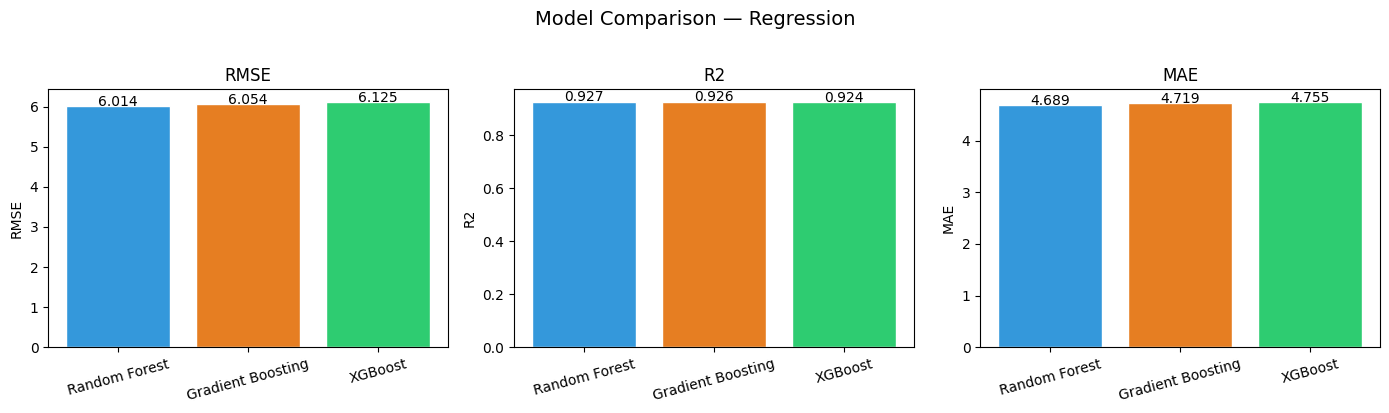

In [15]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting', 'XGBoost'],
    'RMSE': [rf_reg_rmse, gb_reg_rmse, xgb_reg_rmse],
    'R2': [rf_reg_r2, gb_reg_r2, xgb_reg_r2],
    'MAE': [rf_reg_mae, gb_reg_mae, xgb_reg_mae],
    'Clf_Accuracy': [
        accuracy_score(y_test_clf, y_pred_rf_clf),
        accuracy_score(y_test_clf, y_pred_gb_clf),
        accuracy_score(y_test_clf, y_pred_xgb_clf)
    ]
})
print(results.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ['#3498db', '#e67e22', '#2ecc71']
for ax, metric in zip(axes, ['RMSE', 'R2', 'MAE']):
    ax.bar(results['Model'], results[metric], color=colors, edgecolor='white')
    ax.set_title(metric); ax.set_ylabel(metric)
    for i, v in enumerate(results[metric]):
        ax.text(i, v + 0.002, f'{v:.3f}', ha='center', fontsize=10)
    ax.tick_params(axis='x', rotation=15)
plt.suptitle('Model Comparison — Regression', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

In [16]:
# 5-Fold Stratified Cross-Validation on training data
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb_clf, X_train, y_train_clf, cv=skf, scoring='accuracy', n_jobs=-1)

print('=== 5-Fold Cross-Validation (XGBoost Classifier) ===')
print(f'  CV Scores : {cv_scores.round(4)}')
print(f'  Mean      : {cv_scores.mean():.4f}')
print(f'  Std Dev   : {cv_scores.std():.4f}')
print()
print('NOTE: CV accuracy reflects training-set performance (in-distribution).')
print(f'      Hold-out TEST accuracy: {accuracy_score(y_test_clf, y_pred_xgb_clf):.4f}')
print('      The gap is expected — CV sees training patterns; test sees unseen data.')


=== 5-Fold Cross-Validation (XGBoost Classifier) ===
  CV Scores : [0.4033 0.3842 0.3967 0.3967 0.3962]
  Mean      : 0.3954
  Std Dev   : 0.0062

NOTE: CV accuracy reflects training-set performance (in-distribution).
      Hold-out TEST accuracy: 0.3990
      The gap is expected — CV sees training patterns; test sees unseen data.


In [17]:

print('Computing SHAP values... (may take ~30 sec)')
explainer = shap.TreeExplainer(xgb_reg)
shap_values = explainer.shap_values(X_test)
print('Done ✅')

Computing SHAP values... (may take ~30 sec)
Done ✅


/tmp/ipykernel_934/1037186915.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, feature_names=feature_cols,


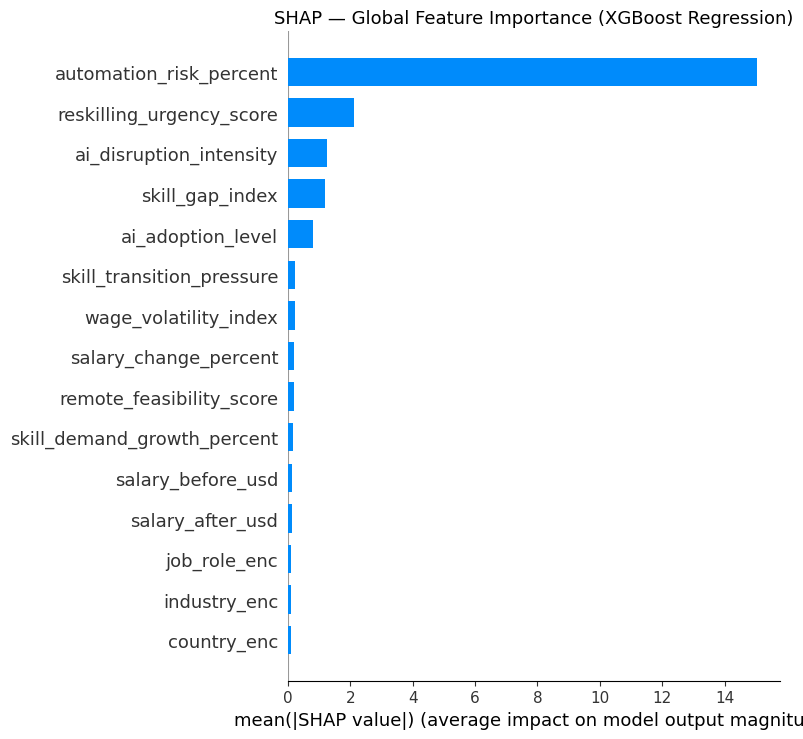

In [18]:

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, feature_names=feature_cols,
                   plot_type='bar', show=False, max_display=15)
plt.title('SHAP — Global Feature Importance (XGBoost Regression)', fontsize=13)
plt.tight_layout()
plt.savefig('shap_summary_bar.png', dpi=120, bbox_inches='tight')
plt.show()

/tmp/ipykernel_934/3301851285.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, feature_names=feature_cols,


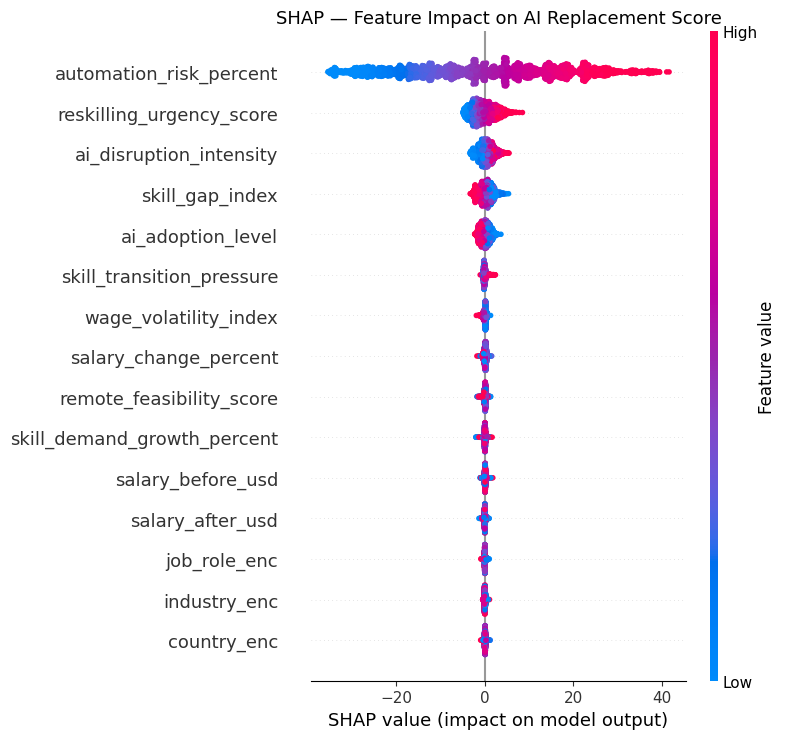

In [19]:
# 2. Beeswarm / Dot Plot — Direction of Impact
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, feature_names=feature_cols,
                   show=False, max_display=15)
plt.title('SHAP — Feature Impact on AI Replacement Score', fontsize=13)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=120, bbox_inches='tight')
plt.show()


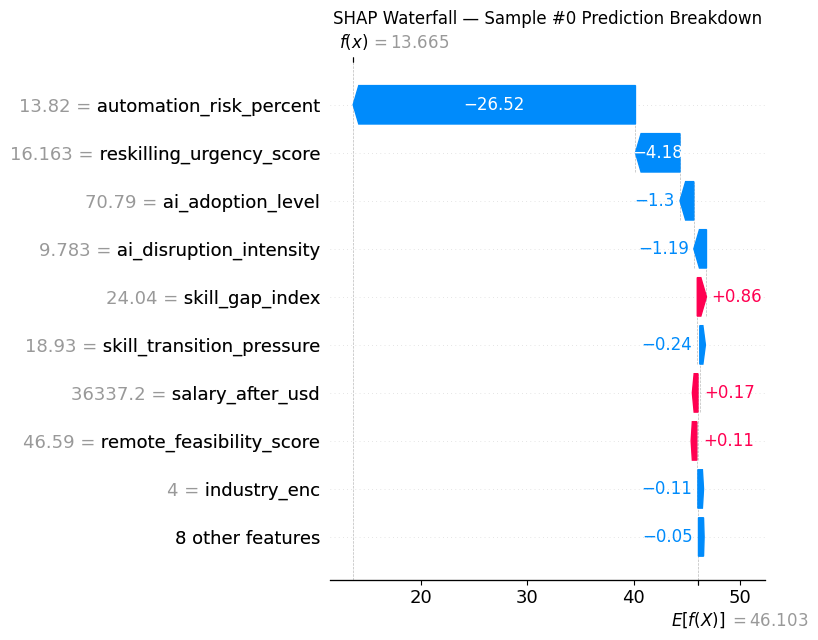

In [20]:
# 3. Waterfall — Single Prediction Explanation
sample_idx = 0
shap_exp = shap.Explanation(
    values=shap_values[sample_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[sample_idx].values,
    feature_names=feature_cols
)
plt.figure(figsize=(10, 5))
shap.waterfall_plot(shap_exp, show=False)
plt.title(f'SHAP Waterfall — Sample #{sample_idx} Prediction Breakdown', fontsize=12)
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=120, bbox_inches='tight')
plt.show()

Top SHAP feature: automation_risk_percent


<Figure size 800x500 with 0 Axes>

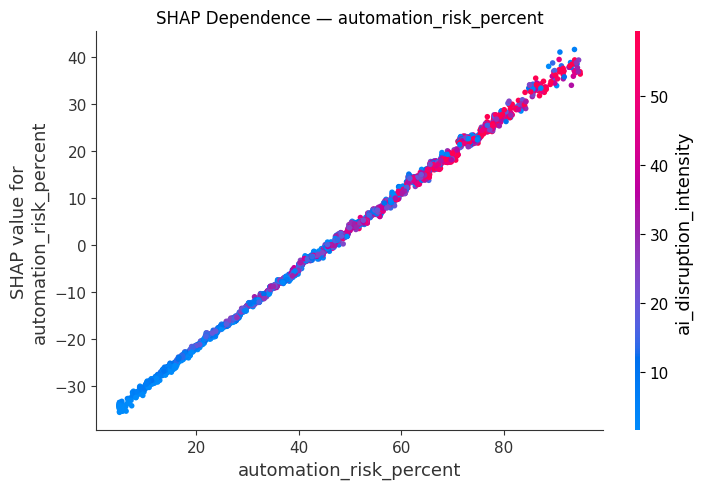

In [21]:
# 4. SHAP Dependence — Top Feature
top_feature = pd.Series(np.abs(shap_values).mean(axis=0),
                         index=feature_cols).idxmax()
print(f'Top SHAP feature: {top_feature}')

plt.figure(figsize=(8, 5))
shap.dependence_plot(top_feature, shap_values, X_test,
                      feature_names=feature_cols, show=False)
plt.title(f'SHAP Dependence — {top_feature}', fontsize=12)
plt.tight_layout()
plt.savefig('shap_dependence.png', dpi=120, bbox_inches='tight')
plt.show()

In [22]:
def run_monte_carlo_job(model, base_row: pd.Series, feature_cols: list,
                         n_simulations: int = 10000,
                         noise_pct: float = 0.10):

    numeric_features = X_test.select_dtypes(include=[np.number]).columns.tolist()
    base_values = base_row[feature_cols].values.copy().astype(float)

    simulated_scores = []
    rng = np.random.default_rng(42)

    for _ in range(n_simulations):
        perturbed = base_values.copy()
        for i, col in enumerate(feature_cols):
            if col in numeric_features:
                std = abs(base_values[i]) * noise_pct
                if std > 0:
                    perturbed[i] += rng.normal(0, std)
        row_df = pd.DataFrame([perturbed], columns=feature_cols)
        pred = model.predict(row_df)[0]
        simulated_scores.append(pred)

    scores = np.array(simulated_scores)
    return {
        'scores': scores,
        'mean': scores.mean(),
        'std': scores.std(),
        'p5': np.percentile(scores, 5),
        'p25': np.percentile(scores, 25),
        'p50': np.percentile(scores, 50),
        'p75': np.percentile(scores, 75),
        'p95': np.percentile(scores, 95),
        'prob_high_risk': (scores >= 70).mean()
    }

In [23]:
# Run Monte Carlo on a sample row
sample_row = X_test.iloc[0]
mc_results = run_monte_carlo_job(xgb_reg, sample_row, feature_cols, n_simulations=10000)

print('=== Monte Carlo Simulation Results ===')
print(f"  Mean AI Replacement Score : {mc_results['mean']:.2f}")
print(f"  Std Deviation             : {mc_results['std']:.2f}")
print(f"  5th  Percentile           : {mc_results['p5']:.2f}")
print(f"  25th Percentile           : {mc_results['p25']:.2f}")
print(f"  Median                    : {mc_results['p50']:.2f}")
print(f"  75th Percentile           : {mc_results['p75']:.2f}")
print(f"  95th Percentile           : {mc_results['p95']:.2f}")
print(f"  P(High Risk, score>=70)   : {mc_results['prob_high_risk']:.1%}")

=== Monte Carlo Simulation Results ===
  Mean AI Replacement Score : 13.87
  Std Deviation             : 1.25
  5th  Percentile           : 11.75
  25th Percentile           : 12.89
  Median                    : 14.03
  75th Percentile           : 14.74
  95th Percentile           : 15.78
  P(High Risk, score>=70)   : 0.0%


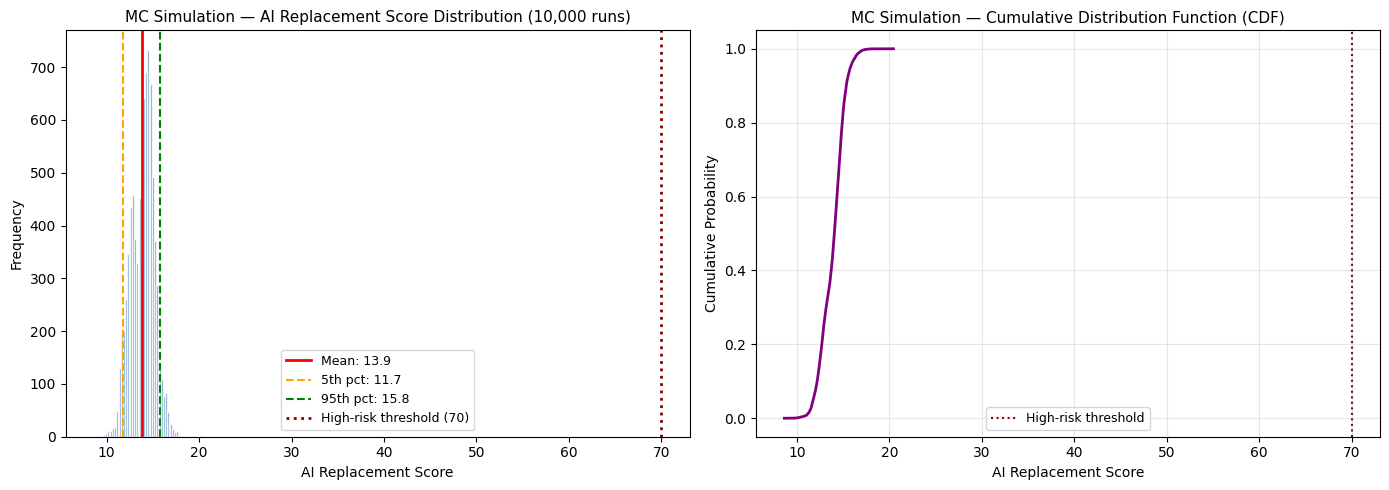

In [24]:
# Visualize MC distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(mc_results['scores'], bins=60, color='steelblue',
              edgecolor='white', alpha=0.85)
axes[0].axvline(mc_results['mean'], color='red', lw=2, label=f"Mean: {mc_results['mean']:.1f}")
axes[0].axvline(mc_results['p5'],   color='orange', lw=1.5, linestyle='--', label=f"5th pct: {mc_results['p5']:.1f}")
axes[0].axvline(mc_results['p95'],  color='green',  lw=1.5, linestyle='--', label=f"95th pct: {mc_results['p95']:.1f}")
axes[0].axvline(70, color='darkred', lw=2, linestyle=':', label='High-risk threshold (70)')
axes[0].set_title('MC Simulation — AI Replacement Score Distribution (10,000 runs)', fontsize=11)
axes[0].set_xlabel('AI Replacement Score'); axes[0].set_ylabel('Frequency')
axes[0].legend(fontsize=9)

# CDF
sorted_scores = np.sort(mc_results['scores'])
cdf = np.arange(1, len(sorted_scores)+1) / len(sorted_scores)
axes[1].plot(sorted_scores, cdf, color='purple', linewidth=2)
axes[1].axvline(70, color='darkred', lw=1.5, linestyle=':', label='High-risk threshold')
axes[1].set_title('MC Simulation — Cumulative Distribution Function (CDF)', fontsize=11)
axes[1].set_xlabel('AI Replacement Score'); axes[1].set_ylabel('Cumulative Probability')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('monte_carlo_results.png', dpi=120, bbox_inches='tight')
plt.show()

In [25]:
import pickle, os


artifacts = {
    'xgb_regressor': xgb_reg,
    'xgb_classifier': xgb_clf,
    'rf_regressor': rf_reg,
    'gb_regressor': gb_reg,
    'label_encoders': le_dict,
    'feature_cols': feature_cols,
    'risk_labels': risk_labels.tolist(),
    'monte_carlo_fn': run_monte_carlo_job
}

with open('job_replacement_models.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print('Models saved ')
print(f'File size: {os.path.getsize("job_replacement_models.pkl") / 1e6:.1f} MB')

Models saved 
File size: 41.1 MB


In [26]:
import sklearn
import numpy
import xgboost

print("sklearn:", sklearn.__version__)
print("numpy:", numpy.__version__)
print("xgboost:", xgboost.__version__)


sklearn: 1.6.1
numpy: 2.0.2
xgboost: 3.2.0
